# Avaliação Prática: Classificação de Espécies de *Tyrannus* com Redes Neurais

Nesta avaliação, você irá projetar e treinar um discriminador feito com uma rede MLP para classificar três espécies de aves do gênero *Tyrannus* com base em medidas morfológicas corporais, utilizando PyTorch.

---

## Contexto

O gênero *Tyrannus* (família Tyrannidae) reúne os chamados "suiriris" e "tesourinhas", aves passeriformes amplamente distribuídas nas Américas. MacPherson et al. mediram características morfológicas de espécimes de museu para investigar a relação entre morfologia e estratégia migratória.

---

## Exercício 1

Projete e treine uma rede neural MLP em PyTorch que receba o vetor de 2 características morfológicas e produza a classificação entre as três espécies.

### Dados

O banco de dados original conta com diversas características morfológicas por indivíduo. Neste primeiro exercício, utilizaremos apenas 2 delas:

| Coluna | Descrição | Unidade |
|---|---|---|
| `wing_chord` | Comprimento da asa | mm |
| `tail_length` | Comprimento da cauda | mm |

O dataset fornecido já contém apenas essas 2 características. As três classes-alvo são:
- **Classe 0:** *Tyrannus tyrannus* (Suiriri-valente)
- **Classe 1:** *Tyrannus melancholicus* (Suiriri-comum)
- **Classe 2:** *Tyrannus savana* (Tesourinha)

Utilize para treinamento os dados do arquivo [`data_train.csv`](./data_train.csv) e para teste os dados do arquivo [`data_test.csv`](./data_test.csv).

Para fins de comparação, treine também um modelo de regressão logística multiclasse, interpretado como uma rede neural com **zero** camadas ocultas (entrada → camada linear → softmax). Esse modelo serve como referência de desempenho mínimo que sua MLP deve superar.

Considere as seguintes diretrizes:
- Use os dados de teste para monitorar o overfitting e observe as curvas de aprendizado;
- Salve os pesos do modelo ao final de cada época e carregue o melhor modelo segundo a função custo de teste (checkpoint);
- Projete a arquitetura livremente. Número de camadas, neurônios e hiperparâmetros são suas escolhas, e devem ser justificados;
- Use `CrossEntropyLoss`, que incorpora o Softmax internamente; portanto, **não** adicione ativação Softmax na camada de saída.

## Exercício 2: Sexo das aves

O banco de dados também fornece o sexo das aves, bem como características morfológicas adicionais. Para investigar a presença de dimorfismo sexual em *Tyrannus melancholicus*, utilizaremos um conjunto de dados adicional contendo todas as 7 características morfológicas originais, além do sexo de cada indivíduo.

Para este exercício, utilize para treinamento os dados do arquivo [`data_extra_train.csv`](./data_extra_train.csv) e para teste os dados do arquivo [`data_extra_test.csv`](./data_extra_test.csv).

Treine um discriminador MLP cujo objetivo é classificar o **sexo** do indivíduo (variável binária: 0 = fêmea, 1 = macho).

Com base nos resultados obtidos, é possível afirmar que *Tyrannus melancholicus* apresenta dimorfismo sexual nessas características morfológicas? Justifique.

## Instruções para entrega

- O exercício deve ser feito **individualmente**;

- A entrega deve incluir:
  - Um vídeo de no **máximo 1m30s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados, incluindo:

1. Arquitetura escolhida e hiperparâmetros, justificados em células Markdown. Utilize as técnicas para evitar a convergência para mínimos locais e para evitar o *overfitting*, ainda que seja possível obter um bom desempenho com uma rede mais simples;
2. Código completo de treinamento e teste;
3. Curvas de aprendizado (função custo de treino vs. teste);
4. Matriz de confusão, acurácia e F1-score macro no conjunto de teste;
5. Comparação com o modelo de regressão logística, com discussão dos resultados.

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 1m30s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do aluno** no início do programa;

- Sobre o envio no Moodle:
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br,  sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome do aluno em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.

------
## Resolução
### Nome do Aluno: Gabriel Cordeiro Caram
### NUSP: 13862292

### Exercício 1

Importamos as bibliotecas fundamentais para a manipulação dos dados, construção das redes neurais e visualização dos resultados.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay, accuracy_score

Carregamos os dados e separamos as features do target. Aplico o StandardScaler para centralizar e normalizar as features, garantindo que a rede neural convirja de [forma mais rápida e estável](https://medium.com/@mhvasconcelos/distribui%C3%A7%C3%A3o-normal-e-a-biblioteca-standard-scaler-em-python-f21c52070c6b).

In [4]:
train_df = pd.read_csv('data_train.csv')
test_df = pd.read_csv('data_test.csv')

print(train_df.head(3))
print(test_df.head(3))

   wing_chord  tail_length  label
0     115.965       96.360      1
1     103.875      203.675      2
2     106.585       80.370      1
   wing_chord  tail_length  label
0      95.470      146.880      2
1      99.665      192.962      2
2     107.615      230.724      2


In [5]:
features = ['wing_chord', 'tail_length']
target = 'label'

#- **Classe 0:** *Tyrannus tyrannus* (Suiriri-valente)
#- **Classe 1:** *Tyrannus melancholicus* (Suiriri-comum)
#- **Classe 2:** *Tyrannus savana* (Tesourinha)

X_train_raw = train_df[features].values
y_train_raw = train_df[target].values
X_test_raw = test_df[features].values
y_test_raw = test_df[target].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

Para manter o código limpo e evitar repetições entre o Baseline e a MLP, criei uma função de treinamento genérica. Ela itera pelas épocas, calcula as perdas de treino e teste, e salva o state_dict do modelo sempre que a loss de validação diminui.

In [6]:
def train_model(model, criterion, optimizer, epochs=50):
    history = {'train_loss': [], 'test_loss': []}
    best_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)

        test_loss /= len(test_loader.dataset)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_weights = copy.deepcopy(model.state_dict())

    return history, best_weights

Definimos nosso Baseline: uma Regressão Logística Multiclasse. Na prática com PyTorch, isso é apenas uma camada Linear conectando diretamente as 2 features de entrada às 3 classes de saída. Utilizamos entropia cruzada como criterion, como pedido.

In [46]:
def create_baseline_model():
    # Usamos LogSoftmax por recomendação do PyTorch para estabilidade numérica
    return nn.Sequential(
        nn.Linear(2, 3)
    )

baseline_model = create_baseline_model()
criterion = nn.CrossEntropyLoss()
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.01)

baseline_history, baseline_best_wts = train_model(
    baseline_model,
    criterion,
    baseline_optimizer,
    epochs=500
)

Justificativa da Arquitetura e Hiperparâmetros: A arquitetura utiliza uma camada oculta com 16 neurônios e ativação ReLU. Para cumprir as exigências de evitar convergência para mínimos locais, optei pelo otimizador Adam, visto em aula, que utiliza momentos estocásticos para escapar de vales rasos na função de custo. Para evitar o overfitting (mesmo sendo uma rede simples), implementei duas técnicas combinadas: [uma camada de Dropout (com probabilidade de 20%) para evitar coadaptação de neurônios, e Regularização L2 (através do parâmetro weight_decay no otimizador) para penalizar pesos muito grandes](https://medium.com/@arnavchiddarwar25/mastering-overfitting-a-deep-dive-into-dropout-and-l2-regularization-techniques-for-neural-4861032ff91a). A saída finaliza com a camada Linear.

In [44]:
def create_mlp_model():
    return nn.Sequential(
        nn.Linear(2, 16),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(16, 3)
    )

mlp_model = create_mlp_model()

mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.01, weight_decay=1e-4)

mlp_history, mlp_best_wts = train_model(
    mlp_model,
    criterion,
    mlp_optimizer,
    epochs=50
)

Finalmente, carregamos os melhores pesos (salvos com base na menor loss de teste) em ambos os modelos para garantir uma avaliação justa. Em seguida, extraímos as previsões para calcular a acurácia final e plotamos as curvas de aprendizado para análise visual.

Baseline - Acurácia: 1.0000 | F1-Score Macro: 1.0000
MLP      - Acurácia: 1.0000 | F1-Score Macro: 1.0000


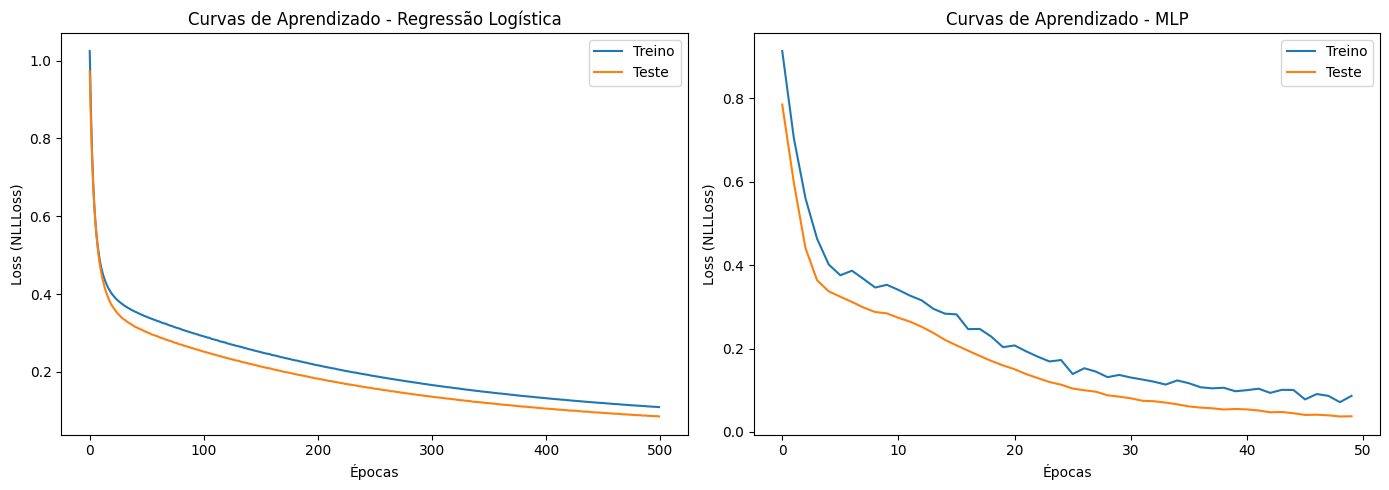

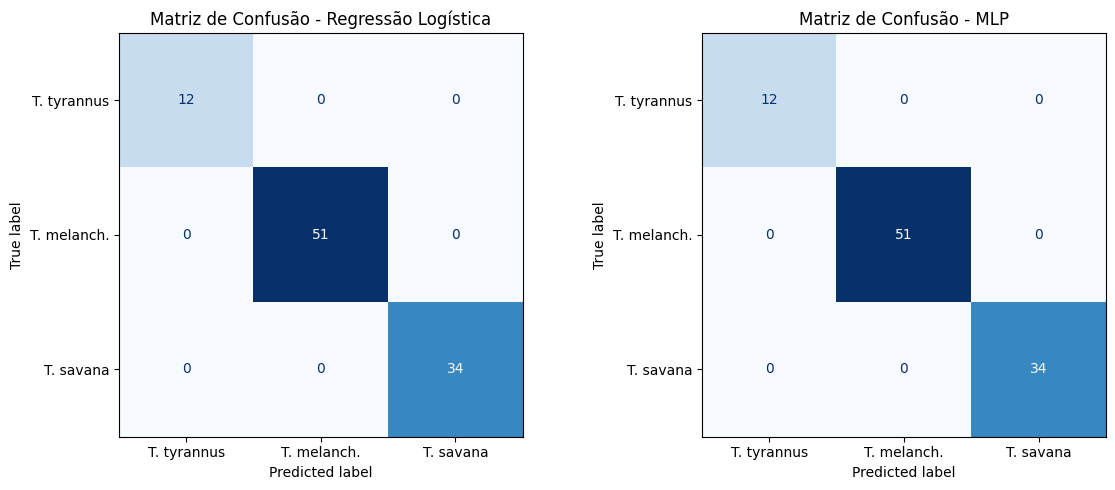

In [49]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            log_probs = model(X_batch)
            preds = torch.argmax(log_probs, dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred_base = get_predictions(baseline_model, test_loader)
_, y_pred_mlp = get_predictions(mlp_model, test_loader)

from sklearn.metrics import accuracy_score

acc_base = accuracy_score(y_true, y_pred_base)
acc_mlp = accuracy_score(y_true, y_pred_mlp)

f1_base = f1_score(y_true, y_pred_base, average='macro')
f1_mlp = f1_score(y_true, y_pred_mlp, average='macro')

print(f"Baseline - Acurácia: {acc_base:.4f} | F1-Score Macro: {f1_base:.4f}")
print(f"MLP      - Acurácia: {acc_mlp:.4f} | F1-Score Macro: {f1_mlp:.4f}")

fig_curves, (ax_curve1, ax_curve2) = plt.subplots(1, 2, figsize=(14, 5))

ax_curve1.plot(baseline_history['train_loss'], label='Treino')
ax_curve1.plot(baseline_history['test_loss'], label='Teste')
ax_curve1.set_title('Curvas de Aprendizado - Regressão Logística')
ax_curve1.set_xlabel('Épocas')
ax_curve1.set_ylabel('Loss')
ax_curve1.legend()

ax_curve2.plot(mlp_history['train_loss'], label='Treino')
ax_curve2.plot(mlp_history['test_loss'], label='Teste')
ax_curve2.set_title('Curvas de Aprendizado - MLP')
ax_curve2.set_xlabel('Épocas')
ax_curve2.set_ylabel('Loss')
ax_curve2.legend()

plt.tight_layout()
plt.show()

fig_cm, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_true, y_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['T. tyrannus', 'T. melanch.', 'T. savana'])
disp_base.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Matriz de Confusão - Regressão Logística')

cm_mlp = confusion_matrix(y_true, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['T. tyrannus', 'T. melanch.', 'T. savana'])
disp_mlp.plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title('Matriz de Confusão - MLP')

plt.tight_layout()
plt.show()

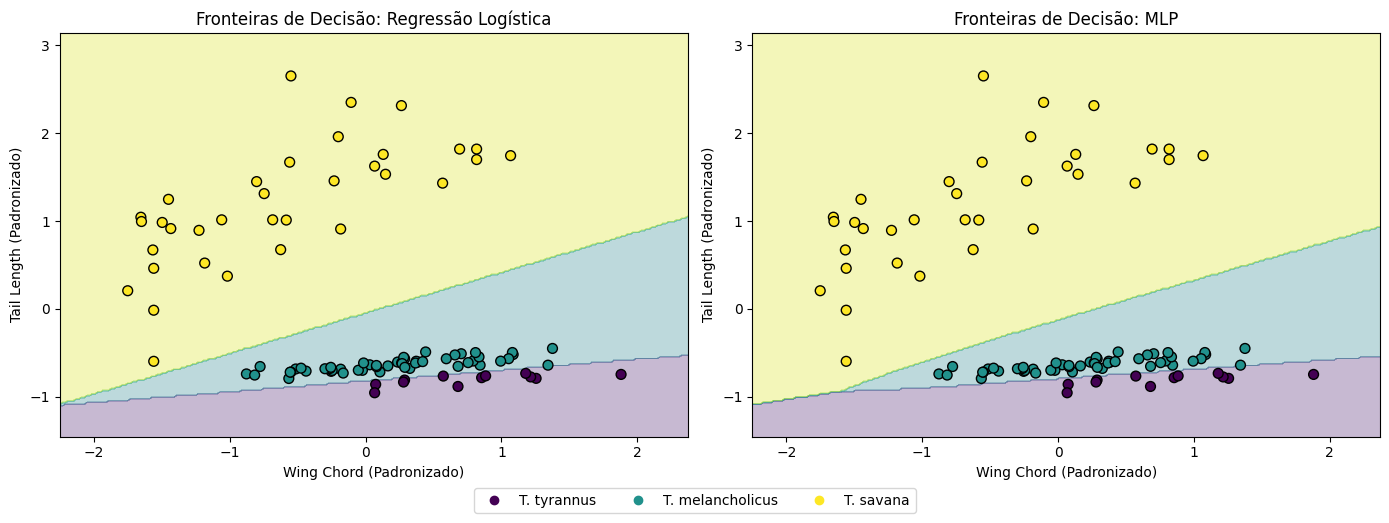

In [48]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        log_probs = model(grid_tensor)
        preds = torch.argmax(log_probs, dim=1)
        Z = preds.numpy().reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis', s=50)
    ax.set_title(title)
    ax.set_xlabel('Wing Chord (Padronizado)')
    ax.set_ylabel('Tail Length (Padronizado)')

    return scatter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

plot_decision_boundary(baseline_model, X_test_np, y_test_np, ax1, 'Fronteiras de Decisão: Regressão Logística')
scatter_ref = plot_decision_boundary(mlp_model, X_test_np, y_test_np, ax2, 'Fronteiras de Decisão: MLP')

legend_labels = ['T. tyrannus', 'T. melancholicus', 'T. savana']
handles, _ = scatter_ref.legend_elements()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

A Regressão Logística (Baseline) estabelece fronteiras de decisão estritamente lineares. Devido à não-linearidade introduzida pela ativação ReLU e à presença da camada oculta, a MLP possui uma capacidade maior de se ajustar a padrões mais complexos na distribuição de wing_chord e tail_length. Nesse caso, os eventos padronizados formam categorias linearmente separáveis, então ambos os modelos atingiram 100% de acurácia, no entanto, a MLP atingiu mais rápido, com 50 épocas apenas. OBS: ao testar com 50 épocas o baseline não atingia 100% de acurácia, como mostrado abaixo:

In [50]:
baseline_model = create_baseline_model()
criterion = nn.CrossEntropyLoss()
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.01)

baseline_history, baseline_best_wts = train_model(
    baseline_model,
    criterion,
    baseline_optimizer,
    epochs=50
)

Baseline - Acurácia: 0.8866 | F1-Score Macro: 0.6855


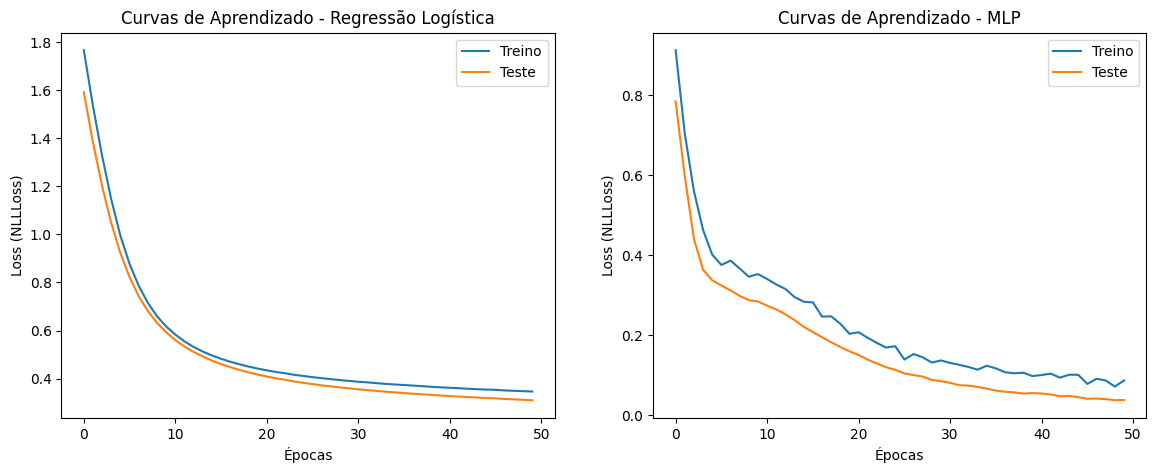

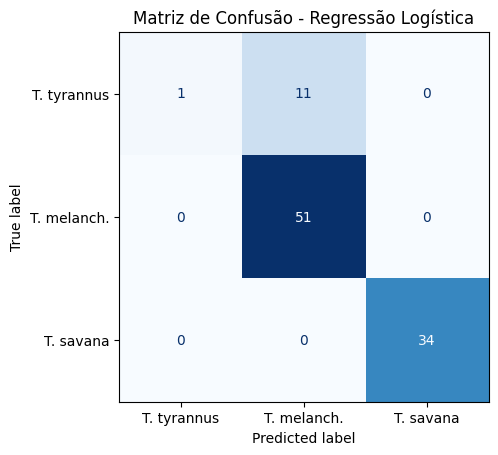

In [51]:
y_true, y_pred_base = get_predictions(baseline_model, test_loader)

acc_base = accuracy_score(y_true, y_pred_base)

f1_base = f1_score(y_true, y_pred_base, average='macro')

print(f"Baseline - Acurácia: {acc_base:.4f} | F1-Score Macro: {f1_base:.4f}")

fig_curves, (ax_curve1, ax_curve2) = plt.subplots(1, 2, figsize=(14, 5))

ax_curve1.plot(baseline_history['train_loss'], label='Treino')
ax_curve1.plot(baseline_history['test_loss'], label='Teste')
ax_curve1.set_title('Curvas de Aprendizado - Regressão Logística')
ax_curve1.set_xlabel('Épocas')
ax_curve1.set_ylabel('Loss')
ax_curve1.legend()

ax_curve2.plot(mlp_history['train_loss'], label='Treino')
ax_curve2.plot(mlp_history['test_loss'], label='Teste')
ax_curve2.set_title('Curvas de Aprendizado - MLP')
ax_curve2.set_xlabel('Épocas')
ax_curve2.set_ylabel('Loss')
ax_curve2.legend()


fig, ax1 = plt.subplots()

cm_base = confusion_matrix(y_true, y_pred_base)
disp_base = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=['T. tyrannus', 'T. melanch.', 'T. savana']
)

disp_base.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Matriz de Confusão - Regressão Logística')

plt.show()

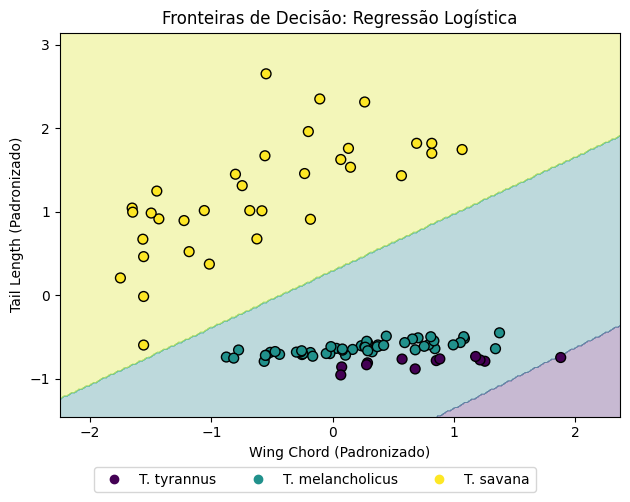

In [43]:
fig, ax1 = plt.subplots()

X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

plot_decision_boundary(baseline_model, X_test_np, y_test_np, ax1, 'Fronteiras de Decisão: Regressão Logística')
scatter_ref = plot_decision_boundary(mlp_model, X_test_np, y_test_np, ax2, 'Fronteiras de Decisão: MLP')

legend_labels = ['T. tyrannus', 'T. melancholicus', 'T. savana']
handles, _ = scatter_ref.legend_elements()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

### Exercício 2

Iniciamos o Exercício 2 importando as bibliotecas e carregando os dados. Como a tabela possui colunas de texto (species) e identificadores de classe (label), selecionamos explicitamente apenas as 7 colunas referentes às características morfológicas para compor nosso vetor de features ($X$). A coluna sex será o nosso alvo ($y$). Aplicamos o StandardScaler apenas nessas 7 variáveis contínuas.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay

# Carregamento dos dados
train_extra_df = pd.read_csv('data_extra_train.csv')
test_extra_df = pd.read_csv('data_extra_test.csv')

print(train_extra_df.head(3))

   bill_length  bill_width  bill_depth  wing_chord  kipps_distance  \
0       16.545      10.000       7.405      120.20          34.075   
1       17.545       9.305       7.620      114.35          31.130   
2       17.680       9.675       7.015      104.46          27.495   

   tail_length  tarsus_length  sex                 species  label  
0        90.06         18.985  1.0  Tyrannus melancholicus      1  
1        96.30         17.770  1.0  Tyrannus melancholicus      1  
2        89.68         18.245  0.0  Tyrannus melancholicus      1  


In [70]:
print(train_extra_df.count())
print(test_extra_df.count())

bill_length       174
bill_width        174
bill_depth        174
wing_chord        174
kipps_distance    174
tail_length       174
tarsus_length     174
sex               174
species           174
label             174
dtype: int64
bill_length       44
bill_width        44
bill_depth        44
wing_chord        44
kipps_distance    44
tail_length       44
tarsus_length     44
sex               44
species           44
label             44
dtype: int64


In [58]:
features = [
    'bill_length', 'bill_width', 'bill_depth',
    'wing_chord', 'kipps_distance', 'tail_length', 'tarsus_length'
]

X_train_raw = train_extra_df[features].values
y_train_raw = train_extra_df['sex'].values

X_test_raw = test_extra_df[features].values
y_test_raw = test_extra_df['sex'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

Abaixo definimos a função genérica de treinamento. Ela iterará pelas épocas, atualizará os pesos e implementará o checkpoint, salvando o estado do modelo (os pesos) sempre que a função de custo (loss) no conjunto de teste for a menor registrada até o momento, como feito no exercício anterior.

In [59]:
def train_model(model, criterion, optimizer, epochs=500):
    history = {'train_loss': [], 'test_loss': []}
    best_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)

        test_loss /= len(test_loader.dataset)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_weights = copy.deepcopy(model.state_dict())

    return history, best_weights

Aqui, fiquei em dúvida se era necessário fazer um baseline com regressão logística como feito no primeiro exercício. Por um lado o exercício 2 não pedia explicitamente uma baselina, mas nas instruções de entrega é dito que a entrega deve incluir "Comparação com o modelo de regressão logística, com discussão dos resultados", não especificamente para um exercício apenas, mas no geral. Logo, por via das dúvidas, farei a baseline para esse exercício também.

Baseline (Regressão Logística): Criamos nosso modelo linear de referência mapeando diretamente as 7 features para as 2 classes de saída. Treinamos por 500 épocas para assegurar a convergência total e carregamos os melhores pesos ao final.

In [64]:
def create_baseline_model():
    return nn.Sequential(
        nn.Linear(7, 2)
    )

baseline_model = create_baseline_model()
criterion = nn.CrossEntropyLoss()
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.005)

baseline_history, baseline_best_wts = train_model(
    baseline_model,
    criterion,
    baseline_optimizer,
    epochs=500
)
baseline_model.load_state_dict(baseline_best_wts)

<All keys matched successfully>

Justificativa da Arquitetura e Hiperparâmetros (MLP): Utilizei uma única camada oculta com 16 neurônios, o que confere não-linearidade suficiente para processar as 7 características sem superdimensionar a rede. Para evitar convergência para mínimos locais, utilizo o otimizador Adam com learning rate de $0.005$. Para evitar overfitting, aplico a técnica de Dropout (probabilidade de 20%) após a ativação ReLU e uma Regularização L2 através do parâmetro weight_decay do Adam (como feito no exercício anterior).

In [67]:
def create_mlp_model():
    return nn.Sequential(
        nn.Linear(7, 16),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(16, 2),
    )

mlp_model = create_mlp_model()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=1e-4)

mlp_history, mlp_best_wts = train_model(
    mlp_model,
    criterion,
    mlp_optimizer,
    epochs=500
)
mlp_model.load_state_dict(mlp_best_wts)

<All keys matched successfully>

Finalmente, realizamos a inferência no conjunto de teste para calcular as métricas de Acurácia e F1-Score Macro. Geramos as matrizes de confusão e plotamos as curvas de aprendizado para a comparação final.

Baseline - Acurácia: 0.6818 | F1-Score Macro: 0.6792
MLP      - Acurácia: 0.7045 | F1-Score Macro: 0.7032


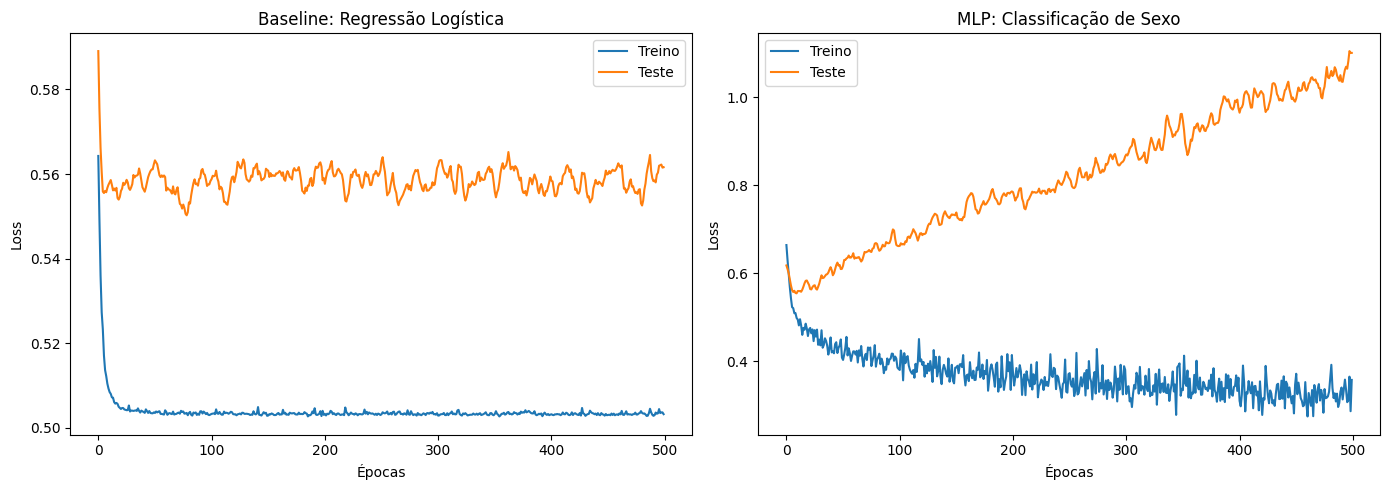

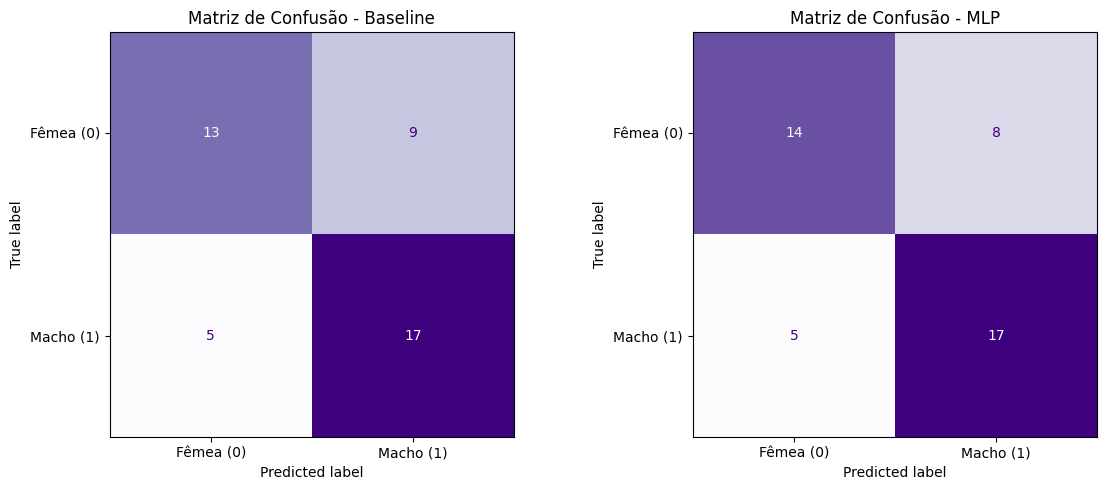

In [68]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            log_probs = model(X_batch)
            preds = torch.argmax(log_probs, dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred_base = get_predictions(baseline_model, test_loader)
_, y_pred_mlp = get_predictions(mlp_model, test_loader)

print(f"Baseline - Acurácia: {accuracy_score(y_true, y_pred_base):.4f} | F1-Score Macro: {f1_score(y_true, y_pred_base, average='macro'):.4f}")
print(f"MLP      - Acurácia: {accuracy_score(y_true, y_pred_mlp):.4f} | F1-Score Macro: {f1_score(y_true, y_pred_mlp, average='macro'):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(baseline_history['train_loss'], label='Treino')
ax1.plot(baseline_history['test_loss'], label='Teste')
ax1.set_title('Baseline: Regressão Logística')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(mlp_history['train_loss'], label='Treino')
ax2.plot(mlp_history['test_loss'], label='Teste')
ax2.set_title('MLP: Classificação de Sexo')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

fig_cm, (ax_cm1, ax_cm2) = plt.subplots(1, 2, figsize=(12, 5))
labels_sexo = ['Fêmea (0)', 'Macho (1)']

disp_base = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_base), display_labels=labels_sexo)
disp_base.plot(ax=ax_cm1, cmap='Purples', colorbar=False)
ax_cm1.set_title('Matriz de Confusão - Baseline')

disp_mlp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_mlp), display_labels=labels_sexo)
disp_mlp.plot(ax=ax_cm2, cmap='Purples', colorbar=False)
ax_cm2.set_title('Matriz de Confusão - MLP')

plt.tight_layout()
plt.show()

Ao que parece, o modelo MLP acabou tendo overfitting, pois o Loss diminuiu nos dados de treino mas aumentou nos dados de teste. Talvez 16 neurônios foram muito para a quantidade de dados de teste e treino (218 dados). Vamos reduzir o número de neurônios e aumentar o dropout e weight_decay para tentar mitigar o overfitting.

In [73]:
def create_mlp_model():
    return nn.Sequential(
        nn.Linear(7, 8),      # Reduzimos de 16 para 8 neurônios
        nn.ReLU(),
        nn.Dropout(0.5),      # Aumentamos o Dropout de 0.2 para 0.5
        nn.Linear(8, 2),
        nn.LogSoftmax(dim=1)
    )

mlp_model = create_mlp_model()

# Aumentamos o weight_decay (L2) de 1e-4 para 1e-2 para punir pesos altos com mais força
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=1e-2)

mlp_history, mlp_best_wts = train_model(
    mlp_model,
    criterion,
    mlp_optimizer,
    epochs=500
)
mlp_model.load_state_dict(mlp_best_wts)

<All keys matched successfully>

Baseline - Acurácia: 0.6818 | F1-Score Macro: 0.6792
MLP      - Acurácia: 0.6818 | F1-Score Macro: 0.6812


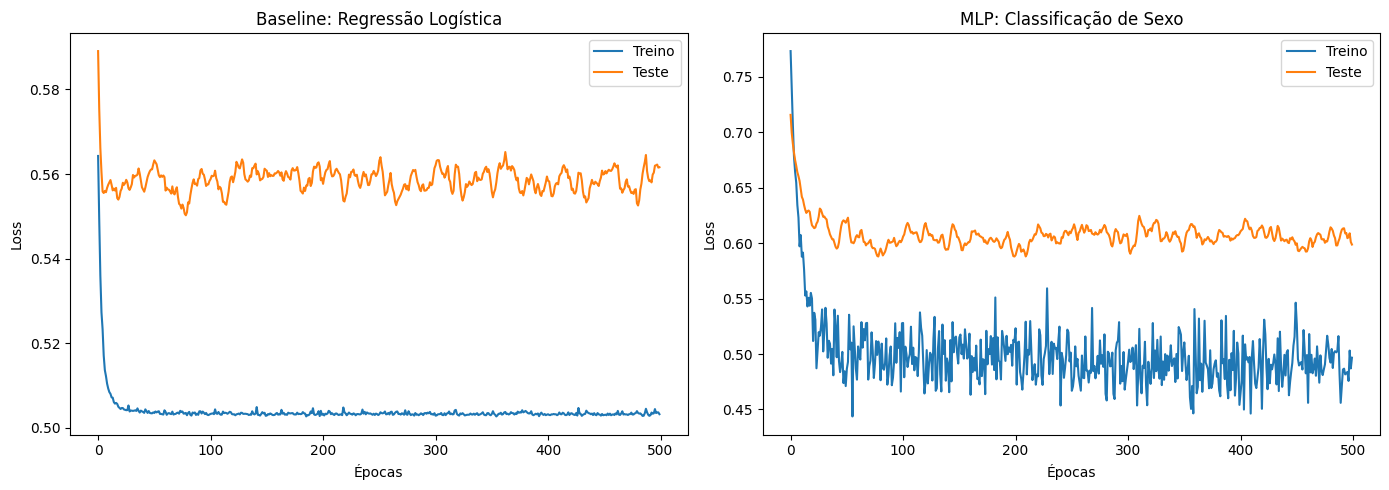

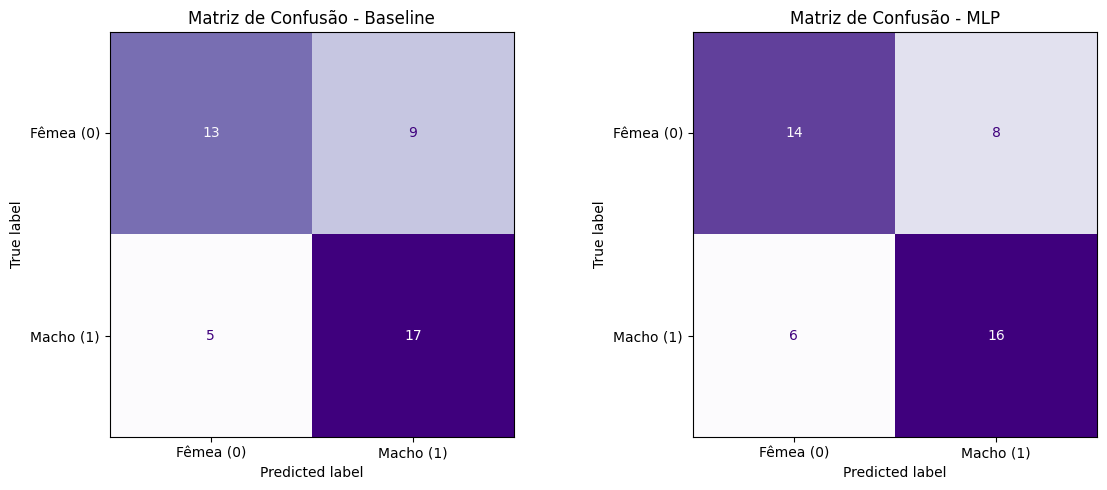

In [74]:
y_true, y_pred_base = get_predictions(baseline_model, test_loader)
_, y_pred_mlp = get_predictions(mlp_model, test_loader)

print(f"Baseline - Acurácia: {accuracy_score(y_true, y_pred_base):.4f} | F1-Score Macro: {f1_score(y_true, y_pred_base, average='macro'):.4f}")
print(f"MLP      - Acurácia: {accuracy_score(y_true, y_pred_mlp):.4f} | F1-Score Macro: {f1_score(y_true, y_pred_mlp, average='macro'):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(baseline_history['train_loss'], label='Treino')
ax1.plot(baseline_history['test_loss'], label='Teste')
ax1.set_title('Baseline: Regressão Logística')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(mlp_history['train_loss'], label='Treino')
ax2.plot(mlp_history['test_loss'], label='Teste')
ax2.set_title('MLP: Classificação de Sexo')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

fig_cm, (ax_cm1, ax_cm2) = plt.subplots(1, 2, figsize=(12, 5))
labels_sexo = ['Fêmea (0)', 'Macho (1)']

disp_base = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_base), display_labels=labels_sexo)
disp_base.plot(ax=ax_cm1, cmap='Purples', colorbar=False)
ax_cm1.set_title('Matriz de Confusão - Baseline')

disp_mlp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_mlp), display_labels=labels_sexo)
disp_mlp.plot(ax=ax_cm2, cmap='Purples', colorbar=False)
ax_cm2.set_title('Matriz de Confusão - MLP')

plt.tight_layout()
plt.show()

Agora não há overfitting aparente, mas ainda o resultado parece um pouco insatisfatório. Pesquisas biológicas mostram que o suriri é uma espécie essencialmente sem dimorfismo sexual, então os resultados obtidos condizem com esse panorama, já que conseguimos um resultado apenas um pouco melhor do que um chute aleatório (68% de acurácia comparada a 50% em um chute aleatório). Sendo assim, nessas características, o algoritmo nos permite concluir que o Tyrannus melancholicus possui dimorfismo sexual sutil.